<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/notebooks/age_prediction_eda_classification_holdout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Age Prediction: data preparation, Exploratory Data Analysis (EDA), and classification with hold-out & nested hold-out

## Data Preparation and Exploratory Data Analysis (EDA)

Import libraries

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading and showing input (features) and output data (desired output)

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print (type(df))

<class 'pandas.core.frame.DataFrame'>


Print the size of the dataframe

In [ ]:
df.shape

(73, 35)

Print the dataframe

In [ ]:
print(df)

    Age Sex  cortex_CT  lh_cortex_CT  rh_cortex_CT  lh_frontalGM_CT  \
0    13   F   2.563765       2.53793       2.58960            2.604   
1    13   M   2.816775       2.80403       2.82952            2.870   
2    16   F   2.590785       2.60300       2.57857            2.659   
3    17   M   2.618340       2.62847       2.60821            2.780   
4    17   M   2.737575       2.77298       2.70217            2.866   
..  ...  ..        ...           ...           ...              ...   
68   14   F   2.785335       2.80093       2.76974            2.956   
69   16   M   2.645850       2.62908       2.66262            2.793   
70   12   F   2.731690       2.73606       2.72732            2.854   
71   10   F   2.674965       2.67007       2.67986            2.749   
72   11   M   2.733215       2.74924       2.71719            2.846   

    lh_occipitalGM_CT  lh_temporalGM_CT  lh_parietalGM_CT  rh_frontalGM_CT  \
0               2.084             2.694             2.432            

Check the features and output variables name

In [ ]:
features = list(df.columns)
type(features)

list

In [ ]:
print(features)

['Age', 'Sex', 'cortex_CT', 'lh_cortex_CT', 'rh_cortex_CT', 'lh_frontalGM_CT', 'lh_occipitalGM_CT', 'lh_temporalGM_CT', 'lh_parietalGM_CT', 'rh_frontalGM_CT', 'rh_occipitalGM_CT', 'rh_temporalGM_CT', 'rh_parietalGM_CT', 'cortex_pial_lgi', 'lh_cortex_pial_lgi', 'rh_cortex_pial_lgi', 'lh_frontal_pial_lgi', 'lh_occipital_pial_lgi', 'lh_temporal_pial_lgi', 'lh_parietal_pial_lgi', 'rh_frontal_pial_lgi', 'rh_occipital_pial_lgi', 'rh_temporal_pial_lgi', 'rh_parietal_pial_lgi', 'cerebralGM_FD', 'lh_cerebralGM_FD', 'lh_frontalGM_FD', 'lh_temporalGM_FD', 'lh_parietalGM_FD', 'lh_occipitalGM_FD', 'rh_cerebralGM_FD', 'rh_frontalGM_FD', 'rh_temporalGM_FD', 'rh_parietalGM_FD', 'rh_occipitalGM_FD']


Plotting some data

Text(0, 0.5, 'cortex CT (mm)')

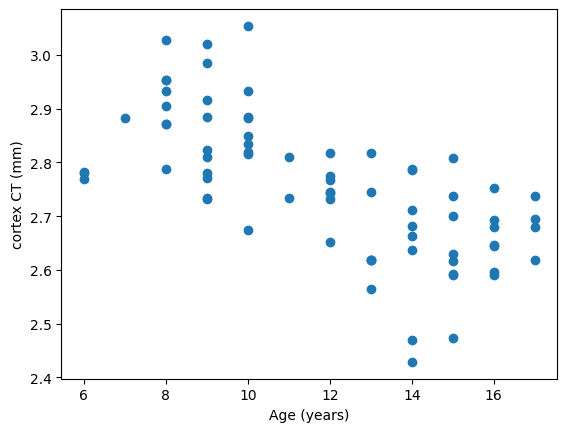

In [ ]:
# Plot true vs predicted values to visualize model performance
plt.scatter(df['Age'],df['cortex_CT'])
plt.xlabel('Age (years)')
plt.ylabel('cortex CT (mm)')

In [ ]:
print("Dataframe shape before NaN removal:", df.shape)

Dataframe shape before NaN removal: (73, 35)


Removing missing data

In [ ]:
df.dropna(axis=0, how='any', inplace=True)
print("Dataframe shape after NaN removal:", df.shape)

Dataframe shape after NaN removal: (72, 35)


Preparing the design matrix X and the desired output y

In [ ]:
X = df.iloc[:,2::]
y = df['Age']
print (type(X))
print (type(y))
print (X.shape)
print (y.shape)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(72, 33)
(72,)


A quick quality control

In [ ]:
X.head(6)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
0,2.563765,2.53793,2.58960,2.604,2.084,2.694,2.432,2.573,2.213,2.901,...,2.4527,2.3947,2.3795,2.3840,2.2441,2.4524,2.4001,2.3942,2.3788,2.2650
1,2.816775,2.80403,2.82952,2.870,2.265,3.188,2.564,2.914,2.244,3.230,...,2.4719,2.4216,2.4228,2.3896,2.2861,2.5181,2.4290,2.4202,2.3942,2.2631
2,2.590785,2.60300,2.57857,2.659,2.058,2.877,2.537,2.649,2.083,2.787,...,2.4854,2.3733,2.3712,2.3852,2.2485,2.4820,2.3681,2.3633,2.3735,2.2511
3,2.618340,2.62847,2.60821,2.780,2.057,2.867,2.459,2.739,2.129,2.880,...,2.4911,2.4034,2.3956,2.3679,2.2631,2.4535,2.3933,2.3921,2.3683,2.2677
4,2.737575,2.77298,2.70217,2.866,2.137,3.194,2.546,2.716,2.204,3.150,...,2.5081,2.4224,2.4194,2.3738,2.2687,2.4641,2.4074,2.4158,2.3694,2.2728
5,2.752830,2.76857,2.73709,2.825,2.172,3.129,2.593,2.702,2.308,3.185,...,2.5024,2.4062,2.4273,2.3702,2.2810,2.4618,2.3929,2.4225,2.3780,2.3053


In [ ]:
print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


## Preparing data for a classification task

Define a function to binarize age

In [ ]:
def categorize_age(age):
    if age <= 11:
        return 0
    elif age >= 12:
        return 1

Binarizing age to obtain two classes

In [ ]:
df['Age_Category'] = df['Age'].apply(categorize_age)

#df['Age_Category'] = df['Age_Category'].astype(int)

# Count the occurrences of each unique value in the 'Age_Category' column
age_category_counts = df['Age_Category'].value_counts()

# Display the counts
print("Number of rows with Age_Category equal to 0:", age_category_counts[0])
print("Number of rows with Age_Category equal to 1:", age_category_counts[1])

Number of rows with Age_Category equal to 0: 32
Number of rows with Age_Category equal to 1: 40


A quick quality control

In [ ]:
df.tail(10)

,Age,Sex,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,...,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD,Age_Category
62,8,F,2.787285,2.80846,2.76611,2.907,2.246,3.126,2.610,2.791,...,2.4368,2.4145,2.4094,2.2956,2.5272,2.4263,2.4145,2.4155,2.3040,0
63,10,F,2.833485,2.84983,2.81714,2.983,2.201,3.170,2.693,2.869,...,2.4215,2.4185,2.4071,2.2692,2.5209,2.4198,2.4269,2.4107,2.2803,0
64,6,F,2.781850,2.79200,2.77170,2.951,2.137,3.004,2.636,2.863,...,2.4316,2.4022,2.4186,2.2810,2.5329,2.4242,2.3997,2.4232,2.2781,0
65,15,M,2.616905,2.65202,2.58179,2.811,1.977,2.977,2.417,2.670,...,2.4212,2.4135,2.3789,2.2515,2.4639,2.4121,2.4097,2.3865,2.1970,1
66,10,M,2.814945,2.82968,2.80021,2.916,2.197,3.148,2.673,2.910,...,2.4330,2.4237,2.4086,2.2657,2.5257,2.4331,2.4230,2.4101,2.2861,0
67,12,M,2.745725,2.74800,2.74345,2.947,2.021,3.044,2.589,2.864,...,2.4355,2.4243,2.4151,2.2684,2.5178,2.4338,2.4212,2.3990,2.2805,1
68,14,F,2.785335,2.80093,2.76974,2.956,2.067,3.147,2.646,2.908,...,2.4271,2.4132,2.3892,2.2572,2.5115,2.4230,2.4198,2.3888,2.2743,1
69,16,M,2.645850,2.62908,2.66262,2.793,2.011,2.912,2.407,2.739,...,2.4038,2.4022,2.3601,2.2468,2.5016,2.4025,2.4116,2.3767,2.2491,1
70,12,F,2.731690,2.73606,2.72732,2.854,2.052,3.025,2.599,2.790,...,2.4146,2.3960,2.3848,2.2327,2.5049,2.4108,2.3926,2.3872,2.2519,1
71,10,F,2.674965,2.67007,2.67986,2.749,2.139,3.098,2.412,2.725,...,2.4150,2.3924,2.3717,2.2553,2.5067,2.4107,2.3956,2.3772,2.2743,0


Extracting "Age_category" and removing the "Age", "Sex" columns from the data

In [ ]:
y = df['Age_Category']
X = df.drop(columns=['Age_Category','Age','Sex'])

# Convert the 'Age_Category' column to integer type
#df['Age_Category'] = df['Age_Category'].astype(int)

print('The whole dataset contains ' + str(X.shape[0]) + ' subjects')
print('The age prediction will be performed using ' + str(X.shape[1]) + ' MRI-derived features')

The whole dataset contains 72 subjects
The age prediction will be performed using 33 MRI-derived features


A quick quality control

In [ ]:
X.tail(10)

,cortex_CT,lh_cortex_CT,rh_cortex_CT,lh_frontalGM_CT,lh_occipitalGM_CT,lh_temporalGM_CT,lh_parietalGM_CT,rh_frontalGM_CT,rh_occipitalGM_CT,rh_temporalGM_CT,...,lh_cerebralGM_FD,lh_frontalGM_FD,lh_temporalGM_FD,lh_parietalGM_FD,lh_occipitalGM_FD,rh_cerebralGM_FD,rh_frontalGM_FD,rh_temporalGM_FD,rh_parietalGM_FD,rh_occipitalGM_FD
62,2.787285,2.80846,2.76611,2.907,2.246,3.126,2.610,2.791,2.304,3.079,...,2.5308,2.4368,2.4145,2.4094,2.2956,2.5272,2.4263,2.4145,2.4155,2.3040
63,2.833485,2.84983,2.81714,2.983,2.201,3.170,2.693,2.869,2.294,3.221,...,2.5201,2.4215,2.4185,2.4071,2.2692,2.5209,2.4198,2.4269,2.4107,2.2803
64,2.781850,2.79200,2.77170,2.951,2.137,3.004,2.636,2.863,2.174,2.978,...,2.5336,2.4316,2.4022,2.4186,2.2810,2.5329,2.4242,2.3997,2.4232,2.2781
65,2.616905,2.65202,2.58179,2.811,1.977,2.977,2.417,2.670,2.042,2.884,...,2.4643,2.4212,2.4135,2.3789,2.2515,2.4639,2.4121,2.4097,2.3865,2.1970
66,2.814945,2.82968,2.80021,2.916,2.197,3.148,2.673,2.910,2.299,3.150,...,2.5283,2.4330,2.4237,2.4086,2.2657,2.5257,2.4331,2.4230,2.4101,2.2861
67,2.745725,2.74800,2.74345,2.947,2.021,3.044,2.589,2.864,2.104,3.127,...,2.5247,2.4355,2.4243,2.4151,2.2684,2.5178,2.4338,2.4212,2.3990,2.2805
68,2.785335,2.80093,2.76974,2.956,2.067,3.147,2.646,2.908,2.137,3.079,...,2.5180,2.4271,2.4132,2.3892,2.2572,2.5115,2.4230,2.4198,2.3888,2.2743
69,2.645850,2.62908,2.66262,2.793,2.011,2.912,2.407,2.739,2.192,2.999,...,2.4936,2.4038,2.4022,2.3601,2.2468,2.5016,2.4025,2.4116,2.3767,2.2491
70,2.731690,2.73606,2.72732,2.854,2.052,3.025,2.599,2.790,2.216,3.082,...,2.5094,2.4146,2.3960,2.3848,2.2327,2.5049,2.4108,2.3926,2.3872,2.2519
71,2.674965,2.67007,2.67986,2.749,2.139,3.098,2.412,2.725,2.232,3.051,...,2.5044,2.4150,2.3924,2.3717,2.2553,2.5067,2.4107,2.3956,2.3772,2.2743


In [ ]:
y.tail(10)

,Age_Category
62,0
63,0
64,0
65,1
66,0
67,1
68,1
69,1
70,1
71,0


## Classification task

### Logistic regression using a holdout scheme

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Setting the seed of the random generator
SEED = 42
# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Creating the splitter
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

In [ ]:
print (X_train.shape, y_train.shape)
print (X_test.shape, y_test.shape)

(64, 33) (64,)
(8, 33) (8,)


In [ ]:
from sklearn.metrics import roc_auc_score

clf_holdout = LogisticRegression(max_iter=1000) #we define the ML model and we train using logistic data
clf_holdout.fit(X_train, y_train)
y_pred_proba_test = clf_holdout.predict_proba(X_test)[:, 1] #the classification model is used with predict_proba
y_pred_proba_train = clf_holdout.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_pred_proba_train) #it is a classification so we use the AUC score
auc_test = roc_auc_score(y_test, y_pred_proba_test)

print("Average AUC training set:", auc_train)
print("Average AUC test set:", auc_test) #we dont have underfitting or overfitting looking at the results

Average AUC training set: 0.968627450980392
Average AUC test set: 1.0


### Logistic Regression with hyperparameter C (Complexity) using a nested holdout scheme

In [ ]:
from sklearn.model_selection import train_test_split

# Setting the seed of the random generator
SEED = 42

# Size of the samples in the test set: e.g., 0.1, means that the test set is composed of 10% of the samples of the entire dataset
test_size = 0.1

# Size of the samples in the validation set: e.g., 0.1, means that the test set is composed of 10% of the samples of the development set
val_size = 0.1

# Outer hold-out
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)

# Print the size of the development and test sets
print ("The development set size is", "X:", X_dev.shape, "y:", y_dev.shape)
print ("The test set size is", "X:", X_test.shape, "y:", y_test.shape)

# Inner hold-out
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=val_size, random_state=SEED)
# Print the size of the training and validation sets
print ("\nThe development set size is", "X:", X_train.shape, "y:", y_train.shape)
print ("The test set size is", "X:", X_val.shape, "y:", y_val.shape)
print()

The development set size is X: (64, 33) y: (64,)
The test set size is X: (8, 33) y: (8,)

The development set size is X: (57, 33) y: (57,)
The test set size is X: (7, 33) y: (7,)



In [24]:
AUC = []

C_list = [0.1, 1, 10, 100] #hyperparameter list

for c in C_list: #loop to test all the possible values in the list
    clf = LogisticRegression(max_iter=1000, C=c).fit(X_train, y_train)
    y_pred_proba_val = clf.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_pred_proba_val)
    print("Average AUC val set:", auc_val, "(",c,")")
    AUC.append (auc_val)
bestC_index = np.argmax(AUC)
bestC = C_list[bestC_index]
print ("\nBest C: ", bestC, "AUC", AUC[bestC_index]) #best C index is the one that gives the highest AUC value

# Re-train the SVR model in the development test using the bestC hyperparameter
clf = LogisticRegression(max_iter=1000,C=bestC).fit(X_dev, y_dev) #we retrain using the best C discovered from the loop

# Apply the model to the test set and compute the MAE
y_pred_test = clf.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba_test)
print("Average AUC test set:", auc_test)


Average AUC val set: 0.9166666666666667 ( 0.1 )
Average AUC val set: 0.9166666666666667 ( 1 )
Average AUC val set: 0.9166666666666667 ( 10 )
Average AUC val set: 0.75 ( 100 )

Best C:  0.1 AUC 0.9166666666666667
Average AUC test set: 1.0
